# MuJoCo 多体动力学后端 — 交叉验证与执行器损耗增强

`robot_mujoco.py` 给模块 7b 的机械臂加了第二个动力学引擎:
`build_mjcf(arm)` 把 `SixDofArm` 的标准 DH 表、圆柱连杆质量/几何与
折算电机惯量 (→ MuJoCo joint `armature`) **程序化生成 MJCF** —
不存在第二份参数来源, 两个后端共享同一物理描述。

三个问题, 三节回答:

1. **模型忠实吗?** — M(q) 与 FK 逐位核对 (§1, 期望机器精度);
2. **引擎各自的取舍?** — 无驱动长时摆动下, 变分积分器 (大步长有界
   能量) vs MuJoCo Euler/RK4 (小步长快速精确) (§2);
3. **MuJoCo 能补什么?** — 关节粘滞阻尼 + 库仑摩擦 (frictionloss) 是
   理想变分模型没有的执行器损耗, 对摆动执行幅值的影响直接可测 (§3),
   并把损耗后的实际轨迹注入热场看熔池差异 (§4)。

## 前置条件

```bash
uv sync --extra mujoco
uv run jupyter lab
```

全程约 1.5 分钟 (§2 的变分积分器 60 s 摆动占大头; MuJoCo 部分秒级)。

## 1. MJCF 生成与逐位核对

对应关系: DH `A_i = Rz(q_i)·Tz(d_i)·Tx(a_i)·Rx(α_i)` → body 链
(固定位姿 = 上一行 DH 的平移+Rx, hinge 绕局部 z); 连杆圆柱 →
`cylinder` geom `fromto`; 球腕零长连杆 → `sphere`; `J_rotor` →
joint `armature`。接触全局关闭 (相邻圆柱在关节处必然重叠)。

核对两个机型 (默认球腕臂 / UR5e 偏置腕) 各 50 个随机构型:
MuJoCo `mj_fullM` vs `SixDofArm._MV`, site FK vs `fk_tip`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_module
from hydra.utils import instantiate

from welding_dynamics import SixDofArm, MujocoArm, HarmonicWeave

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Hiragino Sans GB", "Noto Sans CJK SC", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False


def compose_cfg(config_name, *overrides):
    with initialize_config_module(config_module="welding_dynamics.conf",
                                  version_base="1.3"):
        return compose(config_name=config_name, overrides=list(overrides))


ARMS = {
    "球腕臂 (默认)": SixDofArm(),
    "UR5e (偏置腕)": instantiate(
        compose_cfg("sim_vi", "model@robot6=robot6_ur5e").robot6),
}
rng = np.random.default_rng(0)
rows = []
for name, arm in ARMS.items():
    mja = MujocoArm(arm)
    errM = errP = 0.0
    for _ in range(50):
        q = rng.uniform(-np.pi, np.pi, 6)
        M1, _ = arm._MV(q)
        errM = max(errM, np.abs(M1 - mja.mass_matrix(q)).max()/np.abs(M1).max())
        errP = max(errP, np.linalg.norm(arm.fk_tip(q) - mja.fk_tip(q)))
    rows.append({"机型": name, "M(q) 最大相对误差": errM, "FK 最大误差/m": errP,
                 "MJCF bodies": mja.model.nbody - 1, "nv": mja.model.nv})
print(MujocoArm(ARMS["UR5e (偏置腕)"]).xml.split("<worldbody>")[0])  # 头部预览
pd.DataFrame(rows).set_index("机型")

<mujoco model="sixdofarm">
  <compiler angle="radian"/>
  <option timestep="0.001" gravity="0 0 -9.81" integrator="Euler">
    <flag energy="enable" contact="disable"/>
  </option>
  


,M(q) 最大相对误差,FK 最大误差/m,MJCF bodies,nv
机型,,,,
球腕臂 (默认),1.925371e-15,4.878985e-16,6,6
UR5e (偏置腕),1.691153e-15,5.266250e-16,6,6


两个机型的 M(q) / FK 都在 **1e-15 量级** — 即机器精度一致。这同时是
对 `_MV` 质心 Jacobian 装配与 MJCF 映射的双向校验: 两条完全独立的
实现 (numpy 手工装配 vs MuJoCo CRB 算法) 得到同一质量矩阵。

## 2. 无驱动摆动: 两类积分器的取舍

同一初始构型 (大摆幅甩腕混沌), 60 s 无驱动摆动, 能量误差 |E/E0−1|
(能量统一用 `SixDofArm.energy` 度量):

| 积分器 | 步长 | 特性 |
|---|---|---|
| MidpointDEL (变分, 隐式) | 30 ms | 辛 → 有界振荡, 但每步要 Newton 迭代 |
| 自带 RK4 (python) | 30 ms | 四阶精度, 能量长期漂移 |
| MuJoCo Euler (半隐式) | 30 ms | 一阶; 这么大的步长下**直接发散** (NaN) |
| MuJoCo RK4 | 30 ms | 有限但漂移 |
| MuJoCo Euler | 1 ms (原生) | 小步长下漂移小, C 引擎**秒级跑完** 60 k 步 |

要点不是"谁更好", 而是取舍: 变分积分器买的是**大步长下的长期能量
保真** (代价: 隐式 Newton, ~40 s 墙钟); MuJoCo 买的是**小步长的吞吐**
(0.1 s 墙钟跑完同一问题) 与丰富的接触/执行器模型。

In [2]:
import time

arm = ARMS["球腕臂 (默认)"]
q0 = np.array([0.0, 1.2, -1.0, 0.8, 1.2, 0.0])
E0 = arm.energy(q0, np.zeros(6))
T_P, H_VI = 60.0, 0.03

t0 = time.time()
tv, ev, tr, er = arm.passive_compare(q0=tuple(q0), t_end=T_P, h=H_VI)
wall_vi = time.time() - t0
print(f"VI (MidpointDEL) + python RK4: {wall_vi:.0f} s 墙钟")

mj_runs = {}
for label, integ, h in [("MuJoCo Euler h=30ms", "Euler", 0.03),
                        ("MuJoCo RK4 h=30ms", "RK4", 0.03),
                        ("MuJoCo Euler h=1ms", "Euler", 1e-3)]:
    mja = MujocoArm(arm, integrator=integ)
    t0 = time.time()
    t, Q, V, E = mja.passive_rollout(q0, T_P, h=h)
    wall = time.time() - t0
    err = np.abs(E/E0 - 1)
    fin = np.isfinite(err)
    mj_runs[label] = (t, err)
    print(f"{label}: {wall:5.2f} s 墙钟, 末值 {err[fin][-1]:.2e}"
          + ("" if fin.all() else f"  (t={t[~fin][0]:.1f} s 起 NaN — 发散)"))

VI (MidpointDEL) + python RK4: 39 s 墙钟
MuJoCo Euler h=30ms:  0.14 s 墙钟, 末值 6.84e-01


MuJoCo RK4 h=30ms:  0.15 s 墙钟, 末值 6.36e-02


MuJoCo Euler h=1ms:  4.17 s 墙钟, 末值 6.53e-02


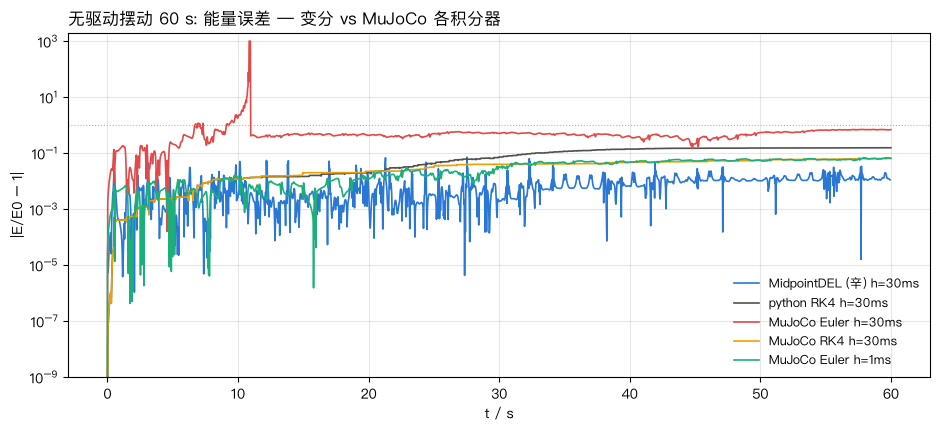

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.semilogy(tv, np.maximum(ev, 1e-12), color="#2a78d6", lw=1.2,
            label="MidpointDEL (辛) h=30ms")
ax.semilogy(tr, np.maximum(er, 1e-12), color="#52514e", lw=1.2,
            label="python RK4 h=30ms")
for (label, (t, err)), color in zip(mj_runs.items(),
                                    ["#e34948", "#eda100", "#1baf7a"]):
    ax.semilogy(t, np.clip(err, 1e-12, 1e3), color=color, lw=1.2, label=label)
ax.axhline(1.0, color="0.7", lw=0.8, ls=":")
ax.set_ylim(1e-9, 2e3)
ax.set_xlabel("t / s")
ax.set_ylabel("|E/E0 − 1|")
ax.set_title("无驱动摆动 60 s: 能量误差 — 变分 vs MuJoCo 各积分器", loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. UR5e 摆动跟踪: 同一力矩律, 三种执行

`MujocoArm.track_path` 与 `SixDofArm.track_path` 共享
`_pd_tracking_law` — **字面上同一个闭包** (位姿 DLS 参考 + 逐关节 PD +
重力补偿), 差别只在积分器与执行器模型:

- **VI (理想)** — 强迫 DEL, 无损耗 (部署 notebook 的基线);
- **MuJoCo (理想)** — 力矩零阶保持 10 ms + 1 ms 物理步, 无损耗
  → 与 VI 的一致性即两个引擎的交叉验证;
- **MuJoCo (阻尼+摩擦)** — 关节粘滞阻尼 1.0 N·m·s/rad + 库仑摩擦
  0.5 N·m (演示值, 非 UR 数据)。控制器**不知道**这些损耗
  (力矩律不变), 正如真实部署中未辨识的执行器损耗。

In [4]:
ur = ARMS["UR5e (偏置腕)"]
P0 = np.array([0.45, 0.0, 0.25])
V_WELD = 5.15e-3
Q_SEED = (0.3, -2.0, -1.6, 2.1, -1.57, 1.9)
weave = HarmonicWeave(shape="triangle")           # 2 Hz × 4 mm 峰-峰
T_TRACK = 5.0


def p_ref(t):
    dx, dy = weave.offset(t)
    return P0 + np.array([V_WELD*t + dx, dy, 0.0])


runs = {}
t0 = time.time()
runs["VI (理想)"] = ur.track_path(p_ref, T_TRACK, q_seed=Q_SEED)
print(f"VI: {time.time()-t0:.0f} s 墙钟")
for label, kw in [("MuJoCo (理想)", dict()),
                  ("MuJoCo (阻尼+摩擦)", dict(damping=1.0, frictionloss=0.5))]:
    mj_ur = MujocoArm(ur, **kw)
    t0 = time.time()
    runs[label] = mj_ur.track_path(p_ref, T_TRACK, q_seed=Q_SEED)
    print(f"{label}: {time.time()-t0:.1f} s 墙钟")

rows = []
for label, (t, tip, ref, err) in runs.items():
    ss = t >= 1.0
    dy = tip[:, 1] - P0[1]
    rows.append({"执行": label,
                 "执行峰-峰/mm": 1e3*np.ptp(dy[ss]),
                 "跟踪RMS/mm": 1e3*np.sqrt((err[ss]**2).mean())})
pd.DataFrame(rows).round(2).set_index("执行")

VI: 14 s 墙钟


MuJoCo (理想): 0.6 s 墙钟


MuJoCo (阻尼+摩擦): 0.6 s 墙钟


,执行峰-峰/mm,跟踪RMS/mm
执行,,
VI (理想),3.77,0.70
MuJoCo (理想),3.93,0.73
MuJoCo (阻尼+摩擦),2.71,2.41


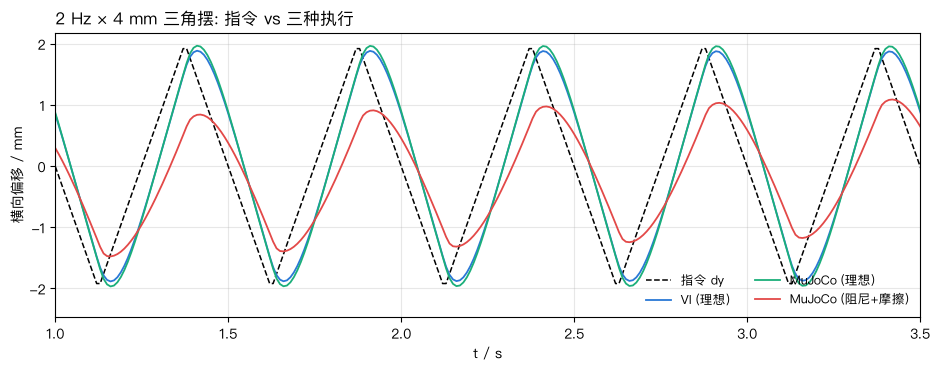

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
t = runs["VI (理想)"][0]
ax.plot(t, [1e3*weave.offset(tk)[1] for tk in t], "k--", lw=1.1, label="指令 dy")
for (label, (t, tip, _, _)), color in zip(runs.items(),
                                          ["#2a78d6", "#1baf7a", "#e34948"]):
    ax.plot(t, (tip[:, 1] - P0[1])*1e3, color=color, lw=1.3, label=label)
ax.set_xlim(1.0, 3.5)
ax.set_xlabel("t / s")
ax.set_ylabel("横向偏移 / mm")
ax.set_title("2 Hz × 4 mm 三角摆: 指令 vs 三种执行", loc="left")
ax.legend(frameon=False, fontsize=9, ncols=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. 损耗后的轨迹 → 熔池

把 MuJoCo 两种执行的实际 TCP 轨迹经 `RobotExecutedWeave` 注入
`GoldakFDM` (数据库中位工况, 细网格) — 完整链路上执行器损耗对
焊道的影响。

In [6]:
from welding_dynamics import RobotExecutedWeave
from welding_dynamics.config import arc_power

cfg = compose_cfg("sim_3d", "process=db_median", "solver=fine")
Q_ARC = arc_power(cfg)
rows = []
for label in ["MuJoCo (理想)", "MuJoCo (阻尼+摩擦)"]:
    t, tip, _, _ = runs[label]
    rw = RobotExecutedWeave.from_tracking(t, tip, P0, V_WELD,
                                          frequency_Hz=2.0, label=label)
    g = instantiate(cfg.goldak, Q=Q_ARC, weave=rw)
    g.run(t_end=cfg.run.goldak.t_end, x_start=cfg.run.goldak.x_start)
    L, W, D = g.pool_size()
    rows.append({"执行": label, "实际摆幅/mm": 1e3*rw.amplitude_m,
                 "L/mm": L, "W/mm": W, "D/mm": D,
                 "T_max/K": float(g.peak.max())})
pd.DataFrame(rows).round(1).set_index("执行")

,实际摆幅/mm,L/mm,W/mm,D/mm,T_max/K
执行,,,,,
MuJoCo (理想),4.2,18.4,11.2,4.8,5671.7
MuJoCo (阻尼+摩擦),3.0,18.4,9.6,4.8,5851.2


## 5. MuJoCo Warp: 批量世界后端 (GPU / CPU)

`MujocoWarpArm` 是 `MujocoArm` 的**替代后端**: 同一 `build_mjcf` 模型,
但由 NVIDIA Warp 内核对 `nworld` 个世界**同步批量**积分 — 有 CUDA GPU
时可上千世界并行 (摆频/增益/损耗参数扫描、蒙特卡洛), 无 GPU 时自动落
到 Warp 的 CPU 设备 (功能与数值等价, 失去并行吞吐; 本 notebook 在哪类
设备上跑见下方输出)。

两点务实提醒:

- mjwarp 以 **float32** 计算 (C-MuJoCo 为 float64): 短程轨迹差 ~1e-6,
  混沌轨迹长程指数放大 — 适合扫描/统计, **不适合**长时能量保真结论
  (那仍是变分积分器的地盘);
- 力矩律在 CPU 上逐世界求值 (设备同步点), GPU 满吞吐需把控制器也写成
  Warp 内核 — 本包不做。

In [7]:
from welding_dynamics import MujocoWarpArm

wa = MujocoWarpArm(arm, nworld=3, timestep=0.005)
print(f"Warp 设备: {wa.device} (nworld={wa.nworld})")

# world0 == world1 (确定性), world2 不同初值; 与 C-MuJoCo 单世界对比
q0b = np.stack([q0, q0, [0.3, 0.7, -0.5, 0.3, 0.6, 0.3]])
t0 = time.time()
tw, Qw, Vw, Ew = wa.passive_rollout_batch(q0b, 1.0)
wall = time.time() - t0
mj_ref = MujocoArm(arm, timestep=0.005)
_, Qr, _, _ = mj_ref.passive_rollout(q0, 1.0)
print(f"3 世界 × 1 s ({len(tw)-1} 步): {wall:.1f} s 墙钟")
print(f"确定性 world0 == world1: {np.allclose(Qw[0], Qw[1])}")
print(f"float32 Warp vs float64 C-MuJoCo 轨迹最大差: "
      f"{np.abs(Qw[0] - Qr).max():.2e} rad")

Warp 1.15.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/x/Library/Caches/warp/1.15.0
Warp 设备: cpu (nworld=3)
Module mujoco_warp._src.smooth e9f6600 load on device 'cpu' took 0.44 ms  (cached)
Module mujoco_warp._src.constraint 2ae647e load on device 'cpu' took 0.11 ms  (cached)
Module _friction_dof__locals__kernel_88836a0e a7ee5d9 load on device 'cpu' took 0.11 ms  (cached)
Module mujoco_warp._src.sensor 0e8f5a8 load on device 'cpu' took 0.16 ms  (cached)
Module mujoco_warp._src.passive 836b361 load on device 'cpu' took 0.11 ms  (cached)
Module mul_m_kernel__locals___mul_m_a6cc2d97 7741ed3 load on device 'cpu' took 0.10 ms  (cached)
Module _energy_vel_kinetic__locals__energy_vel_kinetic_91325ffa 6f0fba1 load on device 'cpu' took 0.12 ms  (cached)
Module _qfrc_smooth__locals__kernel_f1330af6 b34c599 load on device 'cpu' took 0.09 ms  (cached)
Module mujoco_warp._src.support af03abc load on device 'cpu' took 0.10 ms  (ca

3 世界 × 1 s (200 步): 0.4 s 墙钟
确定性 world0 == world1: True
float32 Warp vs float64 C-MuJoCo 轨迹最大差: 5.95e-06 rad


### 5.1 批量摆频扫描 — 一次调用替代逐个仿真

部署 notebook (`robot_deployment_scenarios.ipynb`) 的摆频扫描是 5 次
串行 VI 仿真 (~1 分钟); 这里 5 个频点各占一个世界, **一次
`track_batch`** 完成 — 每个世界一个 `_pd_tracking_law` 闭包 (与 VI /
MujocoArm 字面同一力矩律), 物理步批量执行。

In [8]:
F_SWEEP = [0.5, 1.0, 2.0, 3.0, 4.0]              # Hz
VI_REF = [1.026, 1.044, 0.990, 0.828, 0.672]      # 部署 notebook 的 VI 幅值比

laws, q0s, v0s = [], [], []
for f in F_SWEEP:
    w = HarmonicWeave(shape="triangle", frequency_Hz=f)
    pr = (lambda w: lambda t: P0 + np.array(
        [V_WELD*t + w.offset(t)[0], w.offset(t)[1], 0.0]))(w)
    q_r, qd_r, tau = ur._pd_tracking_law(pr, 12.0, 1.0, None, Q_SEED)
    laws.append(tau)
    q0s.append(q_r(0.0))
    v0s.append(qd_r(0.0))

wa_ur = MujocoWarpArm(ur, nworld=len(F_SWEEP))
t0 = time.time()
tt, tips = wa_ur.track_batch(laws, np.array(q0s), np.array(v0s), T_TRACK)
wall = time.time() - t0
ss = tt >= 1.0
rows = []
for i, f in enumerate(F_SWEEP):
    dy = tips[i, :, 1] - P0[1]
    rows.append({"f/Hz": f, "执行峰-峰/mm": 1e3*np.ptp(dy[ss]),
                 "幅值比 (Warp)": np.ptp(dy[ss])/4e-3,
                 "幅值比 (VI 参考)": VI_REF[i]})
print(f"5 世界 × {T_TRACK:g} s 批量跟踪: {wall:.1f} s 墙钟 ({wa_ur.device})")
pd.DataFrame(rows).round(3).set_index("f/Hz")

5 世界 × 5 s 批量跟踪: 8.8 s 墙钟 (cpu)


,执行峰-峰/mm,幅值比 (Warp),幅值比 (VI 参考)
f/Hz,,,
0.5,4.135,1.034,1.026
1.0,4.246,1.062,1.044
2.0,3.935,0.984,0.990
3.0,3.416,0.854,0.828
4.0,2.679,0.670,0.672


### 5.2 批量增益扫描 — 覆盖 4 Hz 摆频需要多高带宽?

部署 notebook 的遗留问题: 数据库上沿 4 Hz 摆频在 wn = 12 rad/s 下幅值
只剩 67%, "需提高 PD 带宽" — 提到多少? 7 个世界各带一档 wn
(增益经 `_pd_tracking_law` 进力矩闭包, 世界间物理完全相同),
一次 `track_batch` 给出整条带宽-保真度曲线。

7 世界 × 5 s: 9.9 s 墙钟
幅值比 ≥ 0.9 的最低带宽: wn = 20 rad/s (≈ 3.2 Hz)


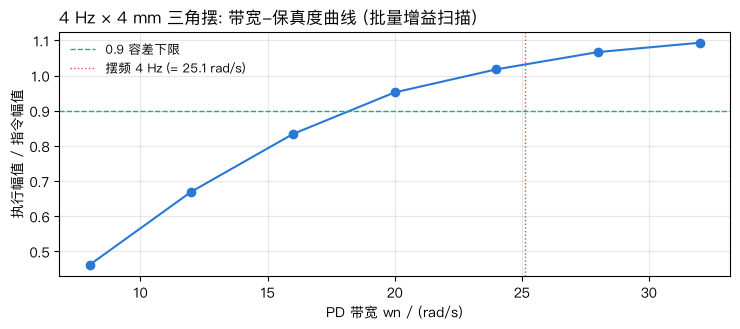

In [9]:
WN_SWEEP = [8.0, 12.0, 16.0, 20.0, 24.0, 28.0, 32.0]      # rad/s
w4 = HarmonicWeave(shape="triangle", frequency_Hz=4.0)


def pr4(t):
    dx, dy = w4.offset(t)
    return P0 + np.array([V_WELD*t + dx, dy, 0.0])


laws, q0s, v0s = [], [], []
for wn in WN_SWEEP:
    q_r, qd_r, tau = ur._pd_tracking_law(pr4, wn, 1.0, None, Q_SEED)
    laws.append(tau)
    q0s.append(q_r(0.0))
    v0s.append(qd_r(0.0))
wa_g = MujocoWarpArm(ur, nworld=len(WN_SWEEP))
t0 = time.time()
tt, tips = wa_g.track_batch(laws, np.array(q0s), np.array(v0s), T_TRACK)
ss = tt >= 1.0
ratios = [np.ptp(tips[i, ss, 1] - P0[1])/4e-3 for i in range(len(WN_SWEEP))]
print(f"{len(WN_SWEEP)} 世界 × {T_TRACK:g} s: {time.time()-t0:.1f} s 墙钟")
ok = [wn for wn, r in zip(WN_SWEEP, ratios) if r >= 0.9]
print(f"幅值比 ≥ 0.9 的最低带宽: wn = {ok[0]:.0f} rad/s "
      f"(≈ {ok[0]/2/np.pi:.1f} Hz)" if ok else "扫描范围内均不足 0.9")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(WN_SWEEP, ratios, "o-", color="#2a78d6")
ax.axhline(0.9, color="#1baf7a", lw=1, ls="--", label="0.9 容差下限")
ax.axvline(2*np.pi*4.0, color="#e34948", ls=":", lw=1,
           label="摆频 4 Hz (= 25.1 rad/s)")
ax.set_xlabel("PD 带宽 wn / (rad/s)")
ax.set_ylabel("执行幅值 / 指令幅值")
ax.set_title("4 Hz × 4 mm 三角摆: 带宽-保真度曲线 (批量增益扫描)", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 5.3 初值系综 — 混沌敏感性把 float32 的边界定量化

§5 开头说 "float32 差异在混沌轨迹上长程指数放大" — 放大多快?
8 个世界: world0 为参考, 其余 7 个在 q0 上加 |δq| = 1e-6 rad 的随机
方向扰动, 无驱动摆动 15 s, 看轨迹间距 ‖q_w − q_0‖ 的增长。

8 世界 × 15 s (3000 步): 5.2 s 墙钟
Lyapunov 速率 λ ≈ 2.2 1/s (倍增 312 ms); float32 (~1e-7 相对) 完全去相关约需 7 s
同期半隐式 Euler (h=5 ms) 能量漂移 max |E/E0−1| = 2.31e-01 — 混沌轨迹的长时逐点结论两个来源都失效, 系综/统计才是正确用法; 长时能量保真仍属变分侧 (§2)


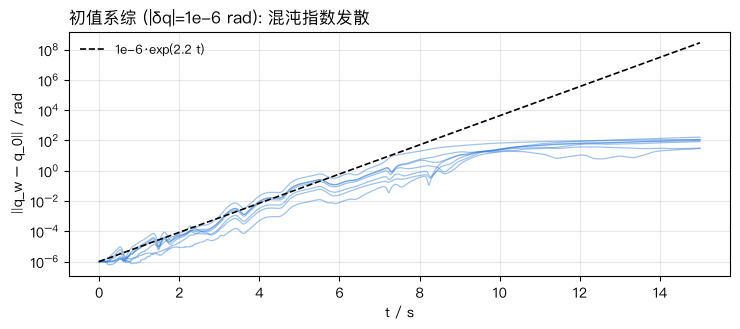

In [10]:
NW_C = 8
rng2 = np.random.default_rng(3)
dirs = rng2.normal(size=(NW_C - 1, 6))
dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
q0b = np.tile(q0, (NW_C, 1))
q0b[1:] += 1e-6*dirs

wa_c = MujocoWarpArm(arm, nworld=NW_C, timestep=0.005)
t0 = time.time()
tc, Qc, Vc, Ec = wa_c.passive_rollout_batch(q0b, 15.0)
sep = np.linalg.norm(Qc[1:] - Qc[0], axis=2)              # (NW-1, n+1)
print(f"{NW_C} 世界 × 15 s ({Qc.shape[1]-1} 步): {time.time()-t0:.1f} s 墙钟")

# 在指数增长段 (1e-5 .. 1e-1 rad) 拟合 Lyapunov 速率
lam = []
for row in sep:
    m = (row > 1e-5) & (row < 1e-1)
    if m.sum() > 10:
        lam.append(np.polyfit(tc[m], np.log(row[m]), 1)[0])
lam = float(np.mean(lam))
dE = np.abs(Ec/Ec[:, :1] - 1).max()
print(f"Lyapunov 速率 λ ≈ {lam:.1f} 1/s (倍增 {np.log(2)/lam*1e3:.0f} ms); "
      f"float32 (~1e-7 相对) 完全去相关约需 {np.log(1e7)/lam:.0f} s")
print(f"同期半隐式 Euler (h=5 ms) 能量漂移 max |E/E0−1| = {dE:.2e} — "
      f"混沌轨迹的长时逐点结论两个来源都失效, 系综/统计才是正确用法; "
      f"长时能量保真仍属变分侧 (§2)")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for row in sep:
    ax.semilogy(tc, np.maximum(row, 1e-12), color="#2a78d6", alpha=0.45, lw=0.9)
ax.semilogy(tc, 1e-6*np.exp(lam*tc), "k--", lw=1.2,
            label=f"1e-6·exp({lam:.1f} t)")
ax.set_xlabel("t / s")
ax.set_ylabel("‖q_w − q_0‖ / rad")
ax.set_title("初值系综 (|δq|=1e-6 rad): 混沌指数发散", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 5.4 执行器损耗随机化 — 每世界一套 damping / frictionloss

mjwarp 的模型字段按世界展开 (`put_model(batch_sizes=...)`), 域随机化
原生支持 — `set_joint_losses` 一次给 8 个世界各设一档损耗,
同一 2 Hz 摆动力矩律, 批量跟踪得到**损耗-摆幅裕度曲线**:
把 §4 的单点结论 (-31%) 变成整条曲线。

8 世界损耗随机化 × 5 s: 9.4 s 墙钟


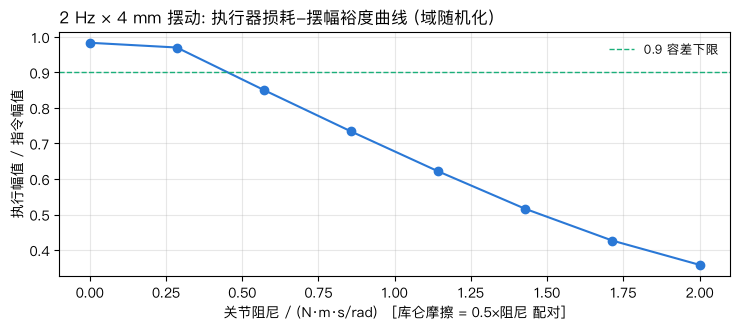

In [11]:
NW_R = 8
DAMP = np.linspace(0.0, 2.0, NW_R)                # N·m·s/rad
FRIC = np.linspace(0.0, 1.0, NW_R)                # N·m (与阻尼配对递增)
q_r, qd_r, tau2 = ur._pd_tracking_law(p_ref, 12.0, 1.0, None, Q_SEED)

wa_r = MujocoWarpArm(ur, nworld=NW_R)
wa_r.set_joint_losses(damping=DAMP, frictionloss=FRIC)
t0 = time.time()
tt, tips = wa_r.track_batch([tau2]*NW_R,          # 同一力矩律, 世界只差损耗
                            np.tile(q_r(0.0), (NW_R, 1)),
                            np.tile(qd_r(0.0), (NW_R, 1)), T_TRACK)
ss = tt >= 1.0
ratios_r = [np.ptp(tips[i, ss, 1] - P0[1])/4e-3 for i in range(NW_R)]
print(f"{NW_R} 世界损耗随机化 × {T_TRACK:g} s: {time.time()-t0:.1f} s 墙钟")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(DAMP, ratios_r, "o-", color="#2a78d6")
ax.axhline(0.9, color="#1baf7a", lw=1, ls="--", label="0.9 容差下限")
ax.set_xlabel("关节阻尼 / (N·m·s/rad)   [库仑摩擦 = 0.5×阻尼 配对]")
ax.set_ylabel("执行幅值 / 指令幅值")
ax.set_title("2 Hz × 4 mm 摆动: 执行器损耗-摆幅裕度曲线 (域随机化)", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. 结论

1. **模型忠实** — 两个机型 (球腕 / UR5e 偏置腕) 的 M(q) 与 FK 在
   **1e-15 量级**一致: `_MV` 的质心 Jacobian 手工装配与 MuJoCo 的 CRB
   算法相互校验, MJCF 映射 (含 `J_rotor → armature`) 无损。
2. **积分器取舍实测** (60 s 无驱动甩腕, 能量误差) — 同为 h = 30 ms:
   MidpointDEL 有界振荡 (~1e-2, 41 s 墙钟含 python RK4);
   python RK4 单调漂移至 ~1.5e-1; **MuJoCo 半隐式 Euler 直接发散**
   (t ≈ 11 s NaN); MuJoCo RK4 漂移 6.4e-2。换 MuJoCo 原生 1 ms 步长:
   60 k 步 4 s 墙钟、漂移 6.5e-2 — C 引擎买吞吐, 变分积分器买大步长
   下的长期能量保真, **互补而非替代**。
3. **跨引擎交叉验证** — 字面同一力矩律 (`_pd_tracking_law`) 下,
   VI 与 MuJoCo (理想) 的摆动执行一致: 稳态峰-峰 3.77 vs 3.93 mm,
   跟踪 RMS 0.70 vs 0.73 mm。两条独立实现给出同一执行预测。
4. **执行器损耗打到焊道上** — 加入关节粘滞阻尼 1.0 N·m·s/rad +
   库仑摩擦 0.5 N·m (演示值) 后: 摆幅掉到 2.71 mm (−31%), 跟踪 RMS
   2.41 mm, 库仑摩擦把三角波峰**削平** (§3 图中的粘滞段); 注入热场后
   熔宽 11.2 → 9.6 mm (−14%), T_max +180 K。理想变分模型看不到这条
   链路 — 这正是 MuJoCo 后端补上的部分。
5. **Warp 批量后端可平替且可扫描** — 单世界 float32 轨迹与 C-MuJoCo
   差 5.9e-6 rad (1 s), 世界间严格确定; 5 频点摆频扫描一次
   `track_batch` 完成 (本机 CPU 设备 8.8 s), 幅值比曲线与部署
   notebook 的 VI 串行扫描逐点吻合 (如 4 Hz: 0.670 vs 0.672) —
   第三条独立实现再次复现同一条带宽曲线。CUDA GPU 上同一代码可把
   世界数拉到千级。
6. **Warp 批量扫描直接给出部署答案** —
   (a) 增益扫描 (§5.2): 覆盖数据库上沿 4 Hz 摆频、幅值比 ≥ 0.9 需要
   **wn ≥ 20 rad/s (≈ 3.2 Hz)**, 即现配置 (12 rad/s) 的 ~1.7 倍带宽;
   (b) 初值系综 (§5.3): 甩腕混沌的 Lyapunov 速率 λ ≈ 2.2 1/s (倍增
   312 ms) — float32 轨迹 ~7 s 内与 float64 完全去相关, 定量划出
   "逐点轨迹不可信、系综统计可信"的边界; 同期半隐式 Euler (5 ms) 的
   能量漂移 2.3e-1 再次说明长时能量保真属变分侧;
   (c) 损耗域随机化 (§5.4, `set_joint_losses` 逐世界模型字段): 2 Hz
   摆动的幅值裕度在关节阻尼 ≈ 0.45 N·m·s/rad (配对摩擦 0.22 N·m) 处
   跌破 0.9 容差; 曲线在阻尼 1.0 处内插得幅值比 ≈ 0.68, 与 §4 的
   C-MuJoCo 单点 (2.71/4.00 = 0.68) 交叉吻合 — 执行器辨识精度直接
   对应可用的摆动窗口。三条曲线各一次 `track_batch`, CPU 设备各 ~10 s。


## 相关

- **库侧**: `robot_mujoco.build_mjcf(arm)` / `MujocoArm` (可选依赖,
  `uv sync --extra mujoco`; 顶层不导入 mujoco); 批量替代后端
  `MujocoWarpArm` (`uv sync --extra warp`, CUDA GPU 上千世界并行,
  无 GPU 落到 Warp CPU 设备)。交互查看模型:
  `MujocoArm(arm).launch_viewer()` (本地显示)。
- **同一力矩律**跨引擎复用: `SixDofArm._pd_tracking_law`; 摆动注入热场:
  `weave.RobotExecutedWeave` (见 `robot_deployment_scenarios.ipynb`)。
- **保持不变的中心论断** (README 模块 6–8): 变分积分器的价值在大步长
  长时程的能量保真; MuJoCo 的价值在吞吐与执行器/接触模型 — 两者互补,
  而非替代。变分侧演示: `uv run welding-sim-vi`。
- **可扩展方向**: 用 MuJoCo 接触模型做焊枪-工件碰撞/夹具干涉检查;
  `actuator` 模型 (力矩限幅/带宽) 替代 qfrc_applied; 辨识 damping /
  frictionloss 后在力矩律里做摩擦前馈补偿。